## Step 1: Import libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

## Step 2: Load sampled dataset

In [2]:
# Load sampled dataset from EDA step
df = pd.read_csv("../data/sample/train_sample_50000.csv")

df.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


## Step 3: Drop ID column

In [3]:
# Remove ID (not useful for prediction)
df = df.drop("id", axis=1)

## Step 4: Check skewness

In [4]:
# Check skewness of features
skewness = df.skew()
skewness.sort_values(ascending=False)

Encroachments                      0.483884
PopulationScore                    0.473763
DeterioratingInfrastructure        0.463791
ClimateChange                      0.456301
TopographyDrainage                 0.454121
WetlandLoss                        0.452634
Siltation                          0.450043
MonsoonIntensity                   0.449562
InadequatePlanning                 0.445426
PoliticalFactors                   0.442709
DamsQuality                        0.441657
IneffectiveDisasterPreparedness    0.441198
Urbanization                       0.437877
Watersheds                         0.435870
Landslides                         0.423693
DrainageSystems                    0.423216
RiverManagement                    0.421374
Deforestation                      0.419833
CoastalVulnerability               0.416825
AgriculturalPractices              0.416572
FloodProbability                   0.051449
dtype: float64

## Step 5: Apply Log Transformation

In [5]:
# Apply log transformation to reduce skewness
df_log = df.copy()

for col in df_log.columns:
    if col != "FloodProbability":
        df_log[col] = np.log1p(df_log[col])  # log(1 + x) to avoid log(0)

## Step 6: Compare distribution (Before vs After)

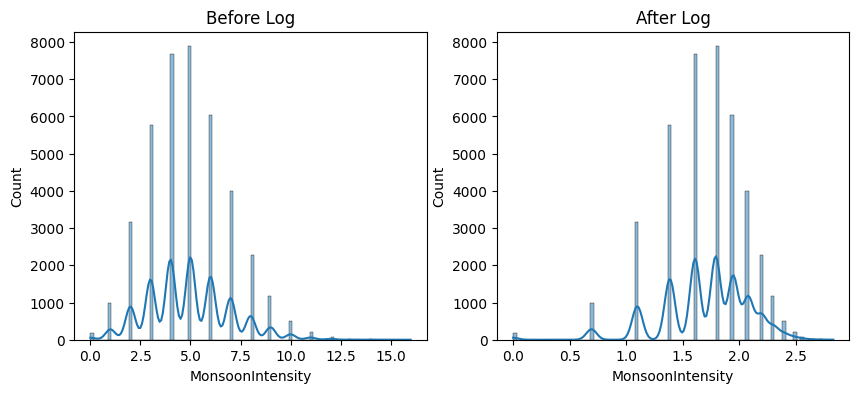

In [6]:
# Compare one feature before vs after log
feature = "MonsoonIntensity"

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df[feature], kde=True)
plt.title("Before Log")

plt.subplot(1,2,2)
sns.histplot(df_log[feature], kde=True)
plt.title("After Log")

plt.show()

## Step 8: Check new correlation

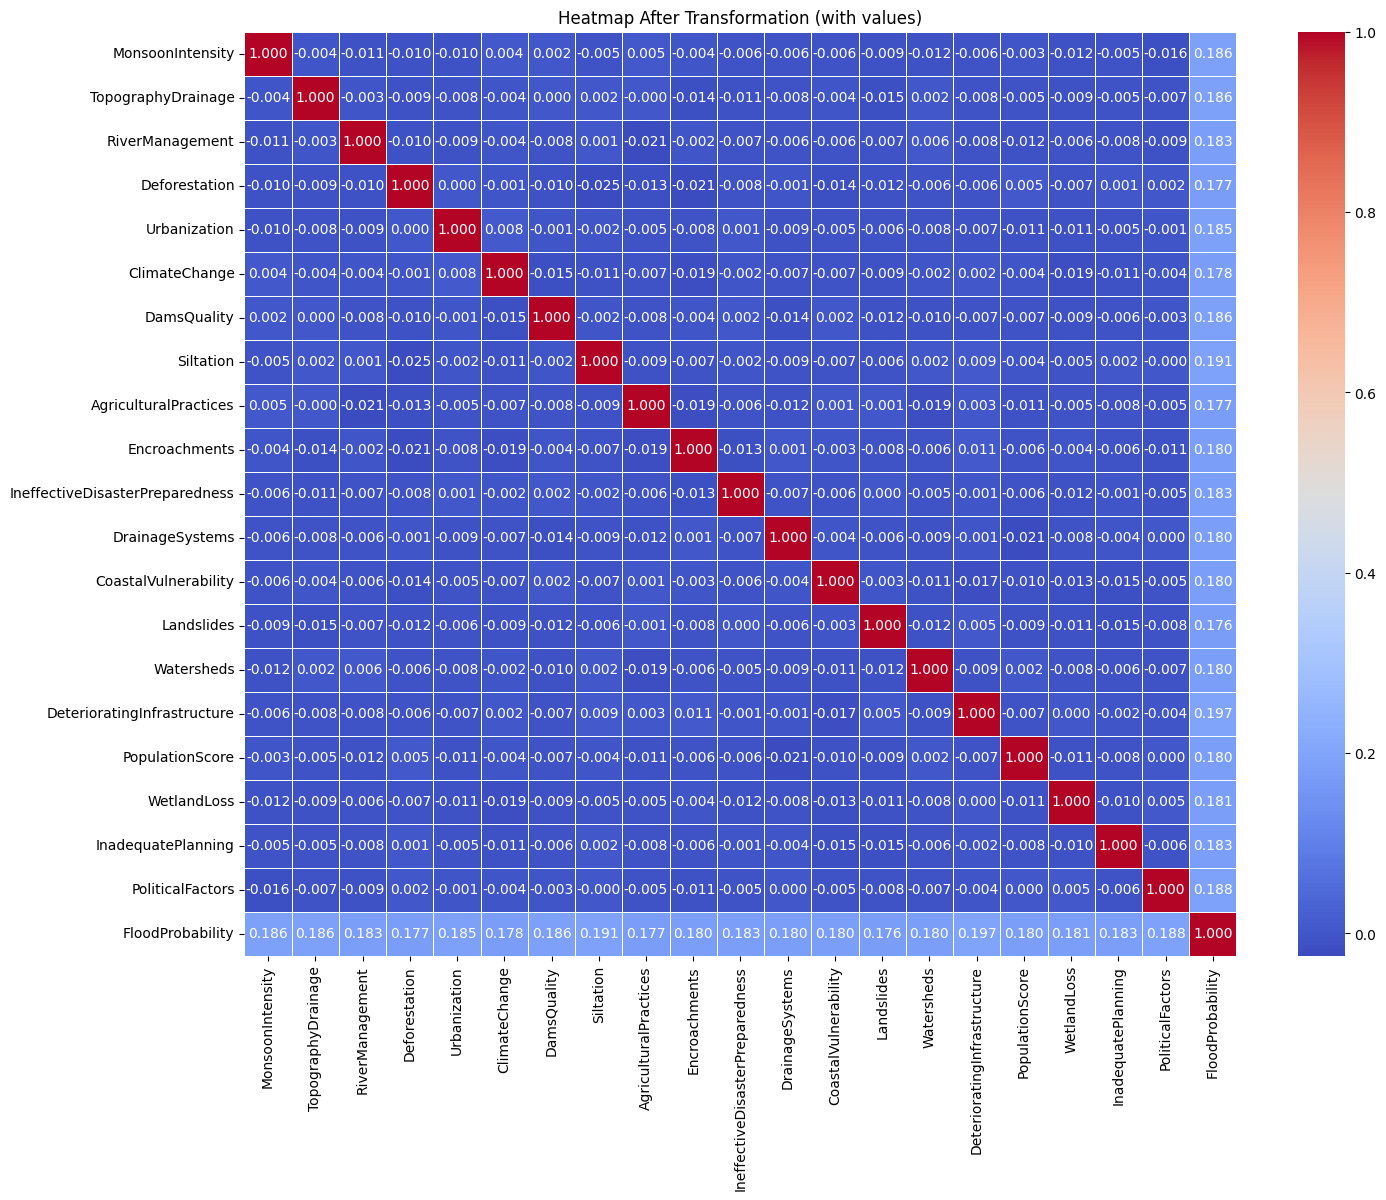

In [7]:
plt.figure(figsize=(16,12))

sns.heatmap(
    df_log.corr(),
    annot=True,        # show numbers
    fmt=".3f",         # 2 decimal places
    cmap="coolwarm",
    linewidths=0.5     # small grid lines for clarity
)

plt.title("Heatmap After Transformation (with values)")
plt.show()

## Step 9: Save processed dataset

In [8]:
# Save transformed dataset for next step
df_log.to_csv("../data/processed/train_transformed.csv", index=False)

In [9]:
df_log.describe()

,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,Encroachments,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
count,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,...,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000,40000.000000
mean,1.711755,1.709284,1.718888,1.716016,1.714752,1.712451,1.713705,1.713925,1.717534,1.717750,...,1.716710,1.717209,1.712209,1.707726,1.711331,1.711881,1.719294,1.717947,1.715154,0.504572
std,0.381054,0.389671,0.384458,0.377898,0.384958,0.379376,0.388245,0.383094,0.382734,0.381958,...,0.384881,0.385752,0.384645,0.389099,0.382289,0.383682,0.382043,0.382408,0.385413,0.050844
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.320000
25%,1.386294,1.386294,1.609438,1.609438,1.386294,1.386294,1.386294,1.386294,1.609438,1.609438,...,1.609438,1.386294,1.386294,1.386294,1.386294,1.386294,1.609438,1.386294,1.386294,0.470000
50%,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,...,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,1.791759,0.505000
75%,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,...,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,1.945910,0.540000
max,2.833213,2.890372,2.833213,2.772589,2.833213,2.833213,2.772589,2.833213,2.833213,2.833213,...,2.890372,2.833213,2.833213,2.833213,2.833213,2.890372,2.833213,2.833213,2.833213,0.715000
